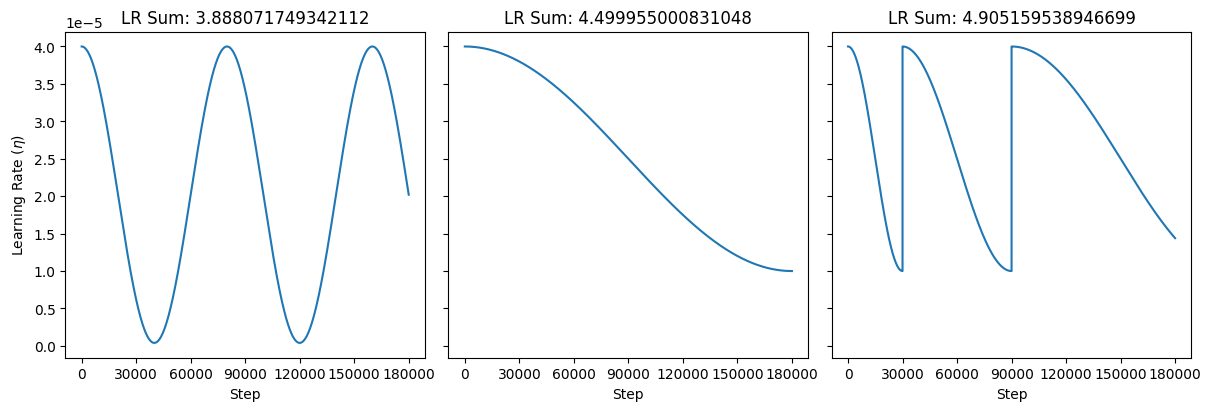

In [17]:
import math
import matplotlib.pyplot as plt
import torch
import numpy as np

from torch.optim.lr_scheduler import CosineAnnealingLR, CosineAnnealingWarmRestarts
from torch.optim import AdamW

fig, (ax1, ax2, ax3) = plt.subplots(ncols=3, figsize=(12, 4), sharey=True, sharex=True, constrained_layout=True)

T_max = 40000
num_steps = 180000
lr = 4e-5
eta_min = 4e-7

optimiser = AdamW([torch.nn.Parameter(torch.zeros(1))], lr=lr)
scheduler = CosineAnnealingLR(optimiser, eta_min=eta_min, T_max=T_max)

xs = list(range(num_steps))
ys = []
for _ in xs:
    scheduler.step()
    eta_cur = scheduler.get_lr()
    ys.append(eta_cur)

ax1.plot(xs, ys)
ax1.set_title(f"LR Sum: {np.sum(ys)}")

T_max = 180000
num_steps = 180000
lr = 4e-5
eta_min = 1e-5

optimiser = AdamW([torch.nn.Parameter(torch.zeros(1))], lr=lr)
scheduler = CosineAnnealingLR(optimiser, eta_min=eta_min, T_max=T_max)

xs = list(range(num_steps))
ys = []
for _ in xs:
    scheduler.step()
    eta_cur = scheduler.get_lr()
    ys.append(eta_cur)

ax2.plot(xs, ys)

ax1.set_ylabel(f"Learning Rate ($\eta$)")
ax1.set_xlabel("Step")
ax2.set_xlabel("Step")
ax2.set_xticks(range(0, 180001, 30000))
ax2.set_title(f"LR Sum: {np.sum(ys)}")

T_max = 30000
num_steps = 180000
lr = 4e-5
eta_min = 1e-5

optimiser = AdamW([torch.nn.Parameter(torch.zeros(1))], lr=lr)
scheduler = CosineAnnealingWarmRestarts(
    optimiser, 
    T_0=T_max,
    T_mult=2,
    eta_min=eta_min,
)
xs = list(range(num_steps))
ys = []
for _ in xs:
    scheduler.step()
    ys.append(scheduler.get_lr())
    
ax3.plot(xs, ys)
ax3.set_xlabel("Step")
ax3.set_title(f"LR Sum: {np.sum(ys)}")
ax3.set_xticks(range(0, 180001, 30000))

plt.show()

3.888071749342112